# Cost-Based Threshold Analysis and Logistic Regression Benchmark

This notebook extends the main analysis (`loan_default_prediction.ipynb`) with two business-focused questions:

1. **Which decision cut-off minimises expected lending cost?** The main analysis used the default cut-off of 0.5, which treats a missed defaulter and a wrongly rejected good customer as equally costly. They are not.
2. **Does a simpler, explainable model perform as well?** A logistic regression is compared with the selected neural network (Config 5).

The data preparation and model are identical to the main notebook. The cut-off is chosen on the **validation set** and then evaluated on the untouched **test set**, so the reported savings are not tuned to the test data.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## 1. Data preparation (same as the main notebook)

In [2]:
df = pd.read_csv("simulated_loan_default_10000.csv")

# Split the issue date into year and month, then drop identifiers
df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month
df = df.drop(columns=["borrower_id", "issue_d"])

y = df["default"]
X = df.drop(columns=["default", "grade"])  # sub_grade carries the same information in more detail

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# 70% train / 15% validation / 15% test, stratified to keep the default rate consistent
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])
P_train = preprocessor.fit_transform(X_train)
P_val = preprocessor.transform(X_val)
P_test = preprocessor.transform(X_test)

weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print("Train / validation / test sizes:", len(X_train), len(X_val), len(X_test))

Train / validation / test sizes: 7000 1500 1500


## 2. Retrain the selected model (Config 5)

In [3]:
# Fix all random seeds and force deterministic operations so results are reproducible
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

model = Sequential([
    layers.Input(shape=(P_train.shape[1],)),
    layers.Dense(128, activation="relu"), layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),  layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),  layers.Dropout(0.25),
    layers.Dense(16, activation="relu"),  layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy")
model.fit(P_train, y_train, validation_data=(P_val, y_val), epochs=30, batch_size=32,
          class_weight=class_weight_dict, verbose=0,
          callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])

nn_val = model.predict(P_val, verbose=0).ravel()
nn_test = model.predict(P_test, verbose=0).ravel()

## 3. Benchmark: logistic regression

In [4]:
logreg = LogisticRegression(max_iter=2000, class_weight="balanced").fit(P_train, y_train)
lr_val = logreg.predict_proba(P_val)[:, 1]
lr_test = logreg.predict_proba(P_test)[:, 1]

def summarise(name, probs):
    pred = (probs >= 0.5).astype(int)
    return {"Model": name,
            "Recall": round(recall_score(y_test, pred), 3),
            "Precision": round(precision_score(y_test, pred), 3),
            "F1": round(f1_score(y_test, pred), 3),
            "AUC": round(roc_auc_score(y_test, probs), 3)}

pd.DataFrame([summarise("Neural network (Config 5)", nn_test),
              summarise("Logistic regression", lr_test)])

,Model,Recall,Precision,F1,AUC
0,Neural network (Config 5),0.657,0.377,0.479,0.737
1,Logistic regression,0.689,0.346,0.461,0.739


## 4. Business cost assumptions

These are illustrative assumptions, stated openly so they can be challenged and changed:

| Error | Business cost | Assumption |
|---|---|---|
| **Missed defaulter** (approved, then defaults) | Loan amount × loss given default | 60% of the loan is lost (typical for unsecured personal lending) |
| **Wrongly flagged good customer** | Lost net profit | 50% of the loan's lifetime interest (the rest covers funding and operating costs) |

Each applicant's own loan amount, interest rate and term are used, so large loans count for more.

In [5]:
def loan_economics(X_part):
    amount = X_part["loan_amnt"].values.astype(float)
    monthly_rate = X_part["int_rate"].values / 100 / 12
    months = np.where(X_part["term"].str.contains("36"), 36, 60)
    payment = amount * monthly_rate / (1 - (1 + monthly_rate) ** -months)
    lifetime_interest = payment * months - amount
    return amount, lifetime_interest

def expected_cost(y_true, probs, amount, interest, cutoff, lgd=0.60, margin=0.50):
    flagged = probs >= cutoff
    missed_defaults = (~flagged) & (y_true == 1)
    wrongly_flagged = flagged & (y_true == 0)
    return {"cutoff": cutoff,
            "cost": (amount[missed_defaults] * lgd).sum() + (interest[wrongly_flagged] * margin).sum(),
            "defaulters_caught": int((flagged & (y_true == 1)).sum()),
            "missed_defaults": int(missed_defaults.sum()),
            "good_flagged": int(wrongly_flagged.sum()),
            "pct_flagged": round(flagged.mean() * 100, 1)}

amt_val, int_val = loan_economics(X_val)
amt_test, int_test = loan_economics(X_test)
yv, yt = y_val.values, y_test.values
print(f"Average loss per missed default: £{(amt_test * 0.6).mean():,.0f}")
print(f"Average lost profit per good customer wrongly flagged: £{(int_test * 0.5).mean():,.0f}")

Average loss per missed default: £12,392
Average lost profit per good customer wrongly flagged: £1,975


## 5. Choose the cut-off on the validation set, evaluate on the test set

In [6]:
cutoffs = np.round(np.arange(0.05, 0.96, 0.01), 2)
val_costs = [expected_cost(yv, nn_val, amt_val, int_val, c)["cost"] for c in cutoffs]
best_cutoff = cutoffs[int(np.argmin(val_costs))]
print("Cost-optimal cut-off chosen on validation set:", best_cutoff)

scenarios = pd.DataFrame([
    {"Scenario": "Approve everyone (no model)", **expected_cost(yt, nn_test, amt_test, int_test, 1.01)},
    {"Scenario": "Model, default cut-off 0.5", **expected_cost(yt, nn_test, amt_test, int_test, 0.5)},
    {"Scenario": f"Model, cost-optimal cut-off {best_cutoff}", **expected_cost(yt, nn_test, amt_test, int_test, best_cutoff)},
])
scenarios["cost"] = scenarios["cost"].map(lambda v: f"£{v/1e6:.2f}m")
scenarios.drop(columns="cutoff")

Cost-optimal cut-off chosen on validation set: 0.25


,Scenario,cost,defaulters_caught,missed_defaults,good_flagged,pct_flagged
0,Approve everyone (no model),£3.60m,0,309,0,0.0
1,"Model, default cut-off 0.5",£2.13m,203,106,335,35.9
2,"Model, cost-optimal cut-off 0.25",£2.10m,292,17,871,77.5


## 6. How flat is the cost curve? (operational trade-off)

In [7]:
rows = [expected_cost(yt, nn_test, amt_test, int_test, c) for c in [0.28, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]]
table = pd.DataFrame(rows)
table["cost"] = table["cost"].map(lambda v: f"£{v/1e6:.2f}m")
table

,cutoff,cost,defaulters_caught,missed_defaults,good_flagged,pct_flagged
0,0.28,£2.08m,282,27,800,72.1
1,0.35,£2.13m,253,56,618,58.1
2,0.40,£2.11m,235,74,500,49.0
3,0.45,£2.11m,218,91,414,42.1
4,0.50,£2.13m,203,106,335,35.9
5,0.55,£2.26m,176,133,268,29.6
6,0.60,£2.51m,137,172,190,21.8


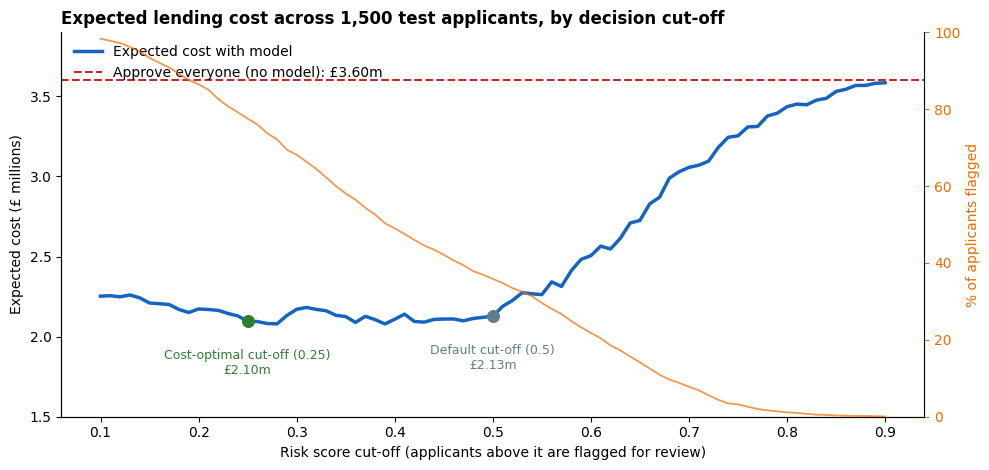

In [8]:
test_cutoffs = np.round(np.arange(0.10, 0.91, 0.01), 2)
test_costs = np.array([expected_cost(yt, nn_test, amt_test, int_test, c)["cost"] for c in test_cutoffs]) / 1e6
pct_flagged = np.array([(nn_test >= c).mean() * 100 for c in test_cutoffs])
no_model = expected_cost(yt, nn_test, amt_test, int_test, 1.01)["cost"] / 1e6

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(test_cutoffs, test_costs, color="#1565c0", lw=2.5, label="Expected cost with model")
ax.axhline(no_model, color="#c62828", ls="--", lw=1.5, label=f"Approve everyone (no model): £{no_model:.2f}m")
for c, label, colour in [(best_cutoff, f"Cost-optimal cut-off ({best_cutoff})", "#2e7d32"), (0.5, "Default cut-off (0.5)", "#607d8b")]:
    v = expected_cost(yt, nn_test, amt_test, int_test, c)["cost"] / 1e6
    ax.scatter([c], [v], s=70, color=colour, zorder=5)
    ax.annotate(f"{label}\n£{v:.2f}m", (c, v), xytext=(0, -38), textcoords="offset points", ha="center", fontsize=9, color=colour)
ax.set_xlabel("Risk score cut-off (applicants above it are flagged for review)")
ax.set_ylabel("Expected cost (£ millions)")
ax.set_title("Expected lending cost across 1,500 test applicants, by decision cut-off", loc="left", fontweight="bold")
ax.set_ylim(1.5, 3.9)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
ax2 = ax.twinx()
ax2.plot(test_cutoffs, pct_flagged, color="#ef6c00", lw=1.3, alpha=0.7)
ax2.set_ylabel("% of applicants flagged", color="#ef6c00")
ax2.tick_params(axis="y", colors="#ef6c00")
ax2.set_ylim(0, 100)
ax2.spines[["top"]].set_visible(False)
plt.tight_layout()
plt.savefig("threshold_cost_analysis.png", dpi=150)
plt.show()

In [9]:
# Sensitivity check: does the conclusion hold if losses on default are lower or higher?
rows = []
for lgd in [0.4, 0.6, 0.8]:
    vc = [expected_cost(yv, nn_val, amt_val, int_val, c, lgd=lgd)["cost"] for c in cutoffs]
    c_best = cutoffs[int(np.argmin(vc))]
    none = expected_cost(yt, nn_test, amt_test, int_test, 1.01, lgd=lgd)["cost"]
    best = expected_cost(yt, nn_test, amt_test, int_test, c_best, lgd=lgd)["cost"]
    rows.append({"Loss given default": f"{int(lgd*100)}%", "Chosen cut-off": c_best,
                 "Saving vs approving everyone": f"{(1 - best/none)*100:.0f}%"})
pd.DataFrame(rows)

,Loss given default,Chosen cut-off,Saving vs approving everyone
0,40%,0.50,28%
1,60%,0.25,42%
2,80%,0.25,55%


## 7. Findings

- **Using the model cuts expected losses by about 42%** compared with approving everyone (£3.60m down to about £2.10m across 1,500 applicants). The saving ranges from 28% to 55% depending on the loss-given-default assumption.
- **The cost curve is almost flat between cut-offs of about 0.25 and 0.50.** Within that range, expected cost varies by only about 2%, but the share of applicants flagged for review more than doubles, from 36% to 78%. Moving to the strict cost-optimal cut-off would save only about 1.5% while requiring far more manual reviews.
- **So the cut-off is really an operational decision about review capacity.** A cut-off of around 0.45 to 0.50 keeps almost all of the financial benefit with a manageable review workload.
- **Setting the cut-off too high is the expensive mistake.** At 0.60, costs rise to £2.51m, as missed defaults grow quickly.
- **Logistic regression performs on par with the neural network** (AUC 0.739 vs 0.737, with higher recall), supporting the recommendation to prefer the simpler, explainable model.

*Note: retraining the neural network in a newer software environment gives very slightly different results from the main notebook (AUC 0.737 vs 0.740), which is normal for neural networks. This notebook fixes all random seeds so its own results are reproducible.*